In [149]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base = Path.cwd()

file_path_train = base.parent.parent /"Data"/"Binary Classification"/"titanic"/"train.csv"
file_path_test = base.parent.parent /"Data"/"Binary Classification"/"titanic"/"test.csv"

print(file_path_train)
print(file_path_train.exists())

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

df_train.head()

c:\Users\takun\OneDrive\Desktop\Stats\Stats\Data\Binary Classification\titanic\train.csv
True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [150]:
df_train.info()
df_train.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [151]:
# # instead of using raw Age, try log-transforming it before scaling
# df_train['Age_log'] = np.log1p(df_train['Age'])
# df_train.drop(columns=['Age'],inplace=True)

In [152]:
import pandas as pd

def drop_columns(df):
    df = df.copy()

    # Columns to drop manually
    drop_list = ["PassengerId", "Name", "Ticket"]

    # Drop columns with >40% missing values
    missing_pct = df.isna().mean()
    missing_cols = missing_pct[missing_pct > 0.40].index.tolist()

    drop_list.extend(missing_cols)
    drop_list = sorted(set(drop_list))

    # Remove dropped columns before analysis
    df = df.drop(columns=drop_list, errors="ignore")

    # Convert obvious categorical variables
    categorical_cols = []

    # Existing object columns
    categorical_cols.extend(
        df.select_dtypes(include=["object", "category"]).columns.tolist()
    )

    # Integer columns with few unique values
    for col in df.select_dtypes(include=["int64", "float64"]).columns:
        if df[col].nunique() <= 10:
            df[col] = df[col].astype("object")
            categorical_cols.append(col)

    categorical_cols = sorted(set(categorical_cols))

    # Summary table
    analysis_data = pd.DataFrame({
        "Name": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "Null Count": df.isnull().sum().values,
        "Unique Value Count": df.nunique().values,
        "Categorical": df.columns.isin(categorical_cols)
    })

    return df, drop_list, categorical_cols, analysis_data

In [153]:
df_clean, drop_list, categorical_cols, analysis_df = drop_columns(df_train)
print(drop_list)
df_clean.head()

['Cabin', 'Name', 'PassengerId', 'Ticket']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [154]:
analysis_df.head(10)

,Name,dtype,Null Count,Unique Value Count,Categorical
0,Survived,object,0,2,True
1,Pclass,object,0,3,True
2,Sex,object,0,2,True
3,Age,float64,177,88,False
4,SibSp,object,0,7,True
5,Parch,object,0,7,True
6,Fare,float64,0,248,False
7,Embarked,object,2,3,True


In [155]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        X_arr = X.values
    else:
        X_arr = np.asarray(X)
        if feature_names is None:
            feature_names = [f"x{i+1}" for i in range(X_arr.shape[1])]
            
    #drop columns that are constant/ all zero, since VIF is undefined for them
    valid_cols = []
    for i in range(X_arr.shape[1]):
        col = X_arr[:, i]
        if np.nanstd(col) == 0:
            print("Skipping '{feature_names[i]}': constant column (VIF Undefined)")
            continue
        valid_cols.append(i)    
    X_valid = X_arr[:, valid_cols]
    valid_names = [feature_names[i] for i in valid_cols]
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = valid_names
    vif_data["VIF"] = [
        variance_inflation_factor(X_valid, i) for i in range(X_valid.shape[1])
    ]
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [156]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


def transform_data(df, target, test_size=0.2, random_state=42,
                    spline_cols=None, spline_df=4, spline_degree=3):
    
    if spline_cols is None:
        spline_cols = []

    df = df.copy()

    # Convert target to a numeric NumPy array
    if pd.api.types.is_categorical_dtype(df[target]):
        y = df[target].cat.codes.to_numpy()
    elif df[target].dtype == object:
        y = pd.factorize(df[target])[0]
    else:
        y = df[target].astype(int).to_numpy()

    df = df.drop(columns=[target])

    dropped_constant_cols = [
        col for col in df.columns
        if df[col].nunique(dropna=False) < 2
    ]
    if dropped_constant_cols:
        print(f"Dropping constant column(s): {dropped_constant_cols}")
        df = df.drop(columns=dropped_constant_cols)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    # Split out the columns that should get a spline basis instead
    # of the standard linear/scaled treatment
    spline_cols = [c for c in spline_cols if c in numeric_cols]
    linear_numeric_cols = [c for c in numeric_cols if c not in spline_cols]

    X_train_df, X_test_df, y_train, y_test = train_test_split(
        df, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Linear numeric preprocessing (unchanged)
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    
    spline_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # scale first, splines behave better on standardized input
        ("spline", SplineTransformer(
            n_knots=spline_df,
            degree=spline_degree,
            include_bias=False
        ))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    transformers = [
        ("num", numeric_transformer, linear_numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
    if spline_cols:
        transformers.append(("spline", spline_transformer, spline_cols))

    preprocessor = ColumnTransformer(transformers)

    X_train = preprocessor.fit_transform(X_train_df)
    X_test = preprocessor.transform(X_test_df)

    return X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df

In [157]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


def run_cv_and_fit(df_clean, target="Survived",
                    spline_cols=None, spline_df=4, spline_degree=3,
                    n_splits=5, random_state=42):

    X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df = transform_data(
    df_clean,
    target=target,
    spline_cols=spline_cols,
    spline_df=spline_df,
    spline_degree=spline_degree,
    random_state=random_state,
)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):

        X_fold_train = X_train[train_idx]
        X_fold_val = X_train[val_idx]

        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        X_fold_train = sm.add_constant(X_fold_train, has_constant="add")
        X_fold_val = sm.add_constant(X_fold_val, has_constant="add")

        try:
            model = sm.Logit(y_fold_train, X_fold_train).fit(disp=False)
        except np.linalg.LinAlgError:
            print(f"Fold {fold}: Singular matrix.")
            continue

        y_prob = model.predict(X_fold_val)
        y_pred = (y_prob >= 0.5).astype(int)

        fold_results.append({
            "Fold": fold,
            "Accuracy": accuracy_score(y_fold_val, y_pred),
            "Precision": precision_score(y_fold_val, y_pred),
            "Recall": recall_score(y_fold_val, y_pred),
            "F1": f1_score(y_fold_val, y_pred),
            "ROC AUC": roc_auc_score(y_fold_val, y_prob)
        })

    cv_results = pd.DataFrame(fold_results)

    print("\nCross Validation Results")
    print(cv_results)

    print("\nAverage Metrics")
    print(cv_results.mean(numeric_only=True).round(3))

    # ------------------------------------------------------------------
    # Train final model on ALL training data
    # ------------------------------------------------------------------

    X_train_const = sm.add_constant(X_train, has_constant="add")
    X_test_const = sm.add_constant(X_test, has_constant="add")

    final_model = sm.Logit(y_train, X_train_const).fit()
    glm_model = sm.GLM(
        y_train,
        X_train_const,
        family=sm.families.Binomial()
    ).fit()

    # ------------------------------------------------------------------
    # Predict on the test set
    # ------------------------------------------------------------------

    y_prob = final_model.predict(X_test_const)
    y_pred = (y_prob >= 0.5).astype(int)

    print("\nTest Accuracy :", accuracy_score(y_test, y_pred))
    print("Test Precision:", precision_score(y_test, y_pred))
    print("Test Recall   :", recall_score(y_test, y_pred))
    print("Test F1       :", f1_score(y_test, y_pred))
    print("Test ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print(final_model.summary())

    return {
        "cv_results": cv_results,
        "final_model": final_model,
        "glm_model": glm_model,
        "preprocessor": preprocessor,
        "X_train": X_train, "X_test": X_test,
        "X_train_const": X_train_const, "X_test_const": X_test_const,
        "y_train": y_train, "y_test": y_test,
        "X_train_df": X_train_df, "X_test_df": X_test_df,
        "y_prob_test": y_prob,
    }

In [158]:
results = run_cv_and_fit(df_clean, target="Survived", spline_cols=["Fare", "Age"], spline_df=4)




cv_results   = results["cv_results"]
final_model  = results["final_model"]
glm_model    = results["glm_model"]
preprocessor = results["preprocessor"]
X_train      = results["X_train"]
X_train_const      = results["X_train_const"]
X_test_const       = results["X_test_const"]
X_train_df      = results["X_train_df"]
X_test_df       = results["X_test_df"]
y_train      = results["y_train"]
y_test       = results["y_test"]
y_prob_test  = results["y_prob_test"]



C:\Users\takun\AppData\Local\Temp\ipykernel_25364\3333409289.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[target]):
C:\Users\takun\AppData\Local\Temp\ipykernel_25364\3333409289.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan)
c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow enco

Fold 2: Singular matrix.

Cross Validation Results
   Fold  Accuracy  Precision    Recall        F1   ROC AUC
0     1  0.811189   0.750000  0.763636  0.756757  0.858781
1     3  0.816901   0.784314  0.727273  0.754717  0.901881
2     4  0.767606   0.677966  0.740741  0.707965  0.832386
3     5  0.816901   0.780000  0.722222  0.750000  0.870581

Average Metrics
Fold         3.250
Accuracy     0.803
Precision    0.748
Recall       0.738
F1           0.742
ROC AUC      0.866
dtype: float64
         Current function value: 0.409483
         Iterations: 35

Test Accuracy : 0.7988826815642458
Test Precision: 0.7796610169491526
Test Recall   : 0.6666666666666666
Test F1       : 0.71875
Test ROC AUC  : 0.8378129117259552

Confusion Matrix
[[97 13]
 [23 46]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179

In [159]:

feature_names = preprocessor.get_feature_names_out()

print(X_train.shape)        # should now match
print(len(feature_names))

vif_df = calculate_vif(X_train, feature_names=feature_names)
print("\nVariance Inflation Factor (VIF) Results")
print(vif_df)

(712, 16)
16

Variance Inflation Factor (VIF) Results
              feature           VIF
0   spline__Fare_sp_1  15614.890364
1    spline__Age_sp_2  12793.246917
2    spline__Age_sp_3   3703.968390
3   spline__Fare_sp_2   3267.407574
4    spline__Age_sp_1   2489.242118
5   spline__Fare_sp_0    665.433595
6    spline__Age_sp_4    366.385744
7   spline__Fare_sp_3    135.632675
8   spline__Fare_sp_4     78.894504
9    spline__Age_sp_0     51.974285
10    cat__Embarked_S      5.394384
11      cat__Sex_male      3.311350
12        num__Pclass      3.197788
13         num__SibSp      1.671055
14    cat__Embarked_Q      1.592640
15         num__Parch      1.587558


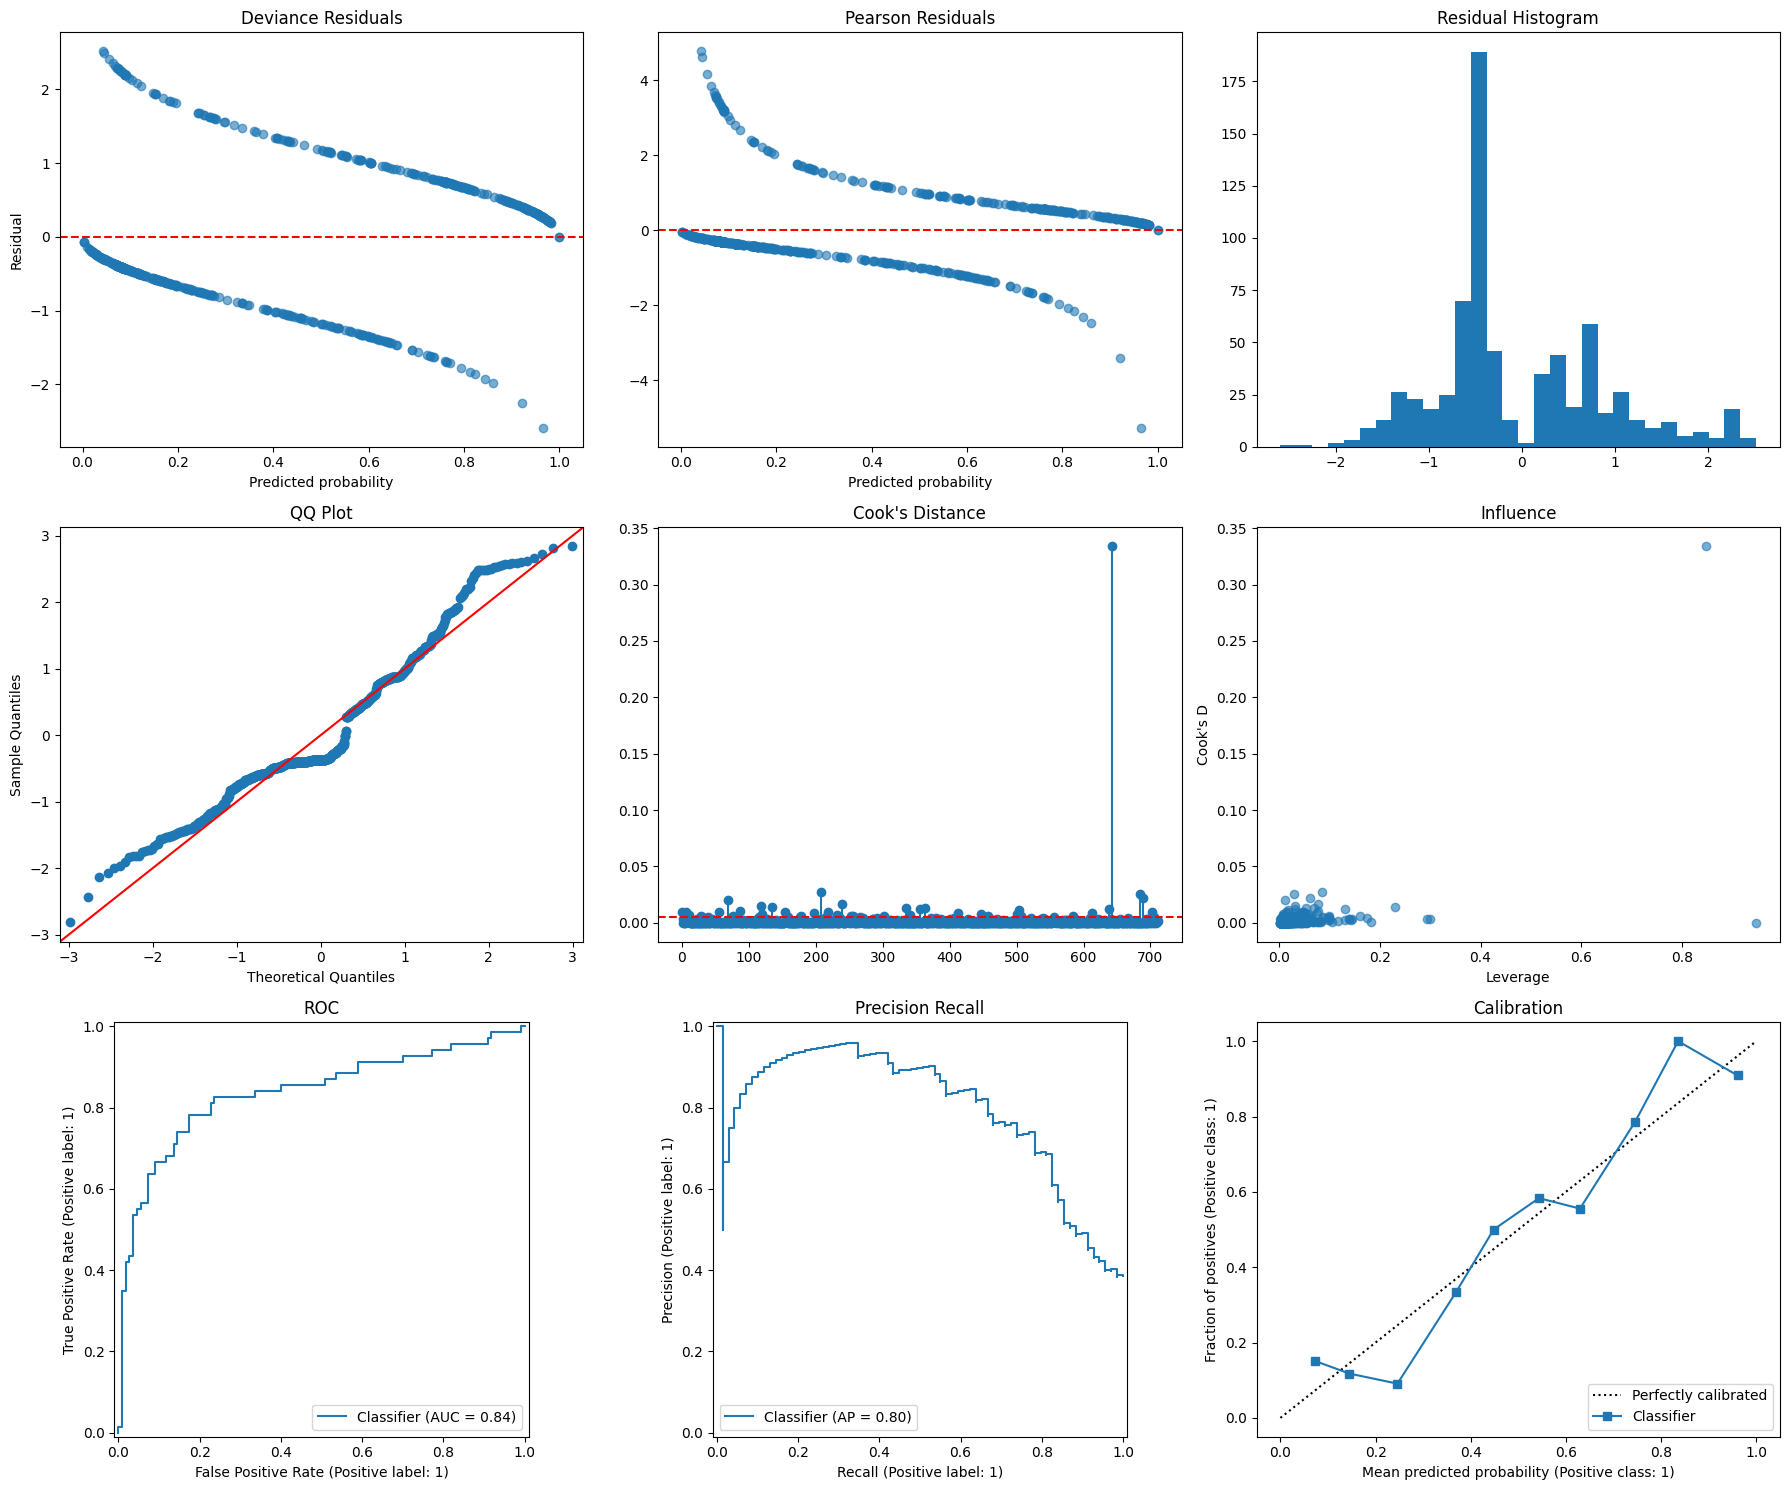

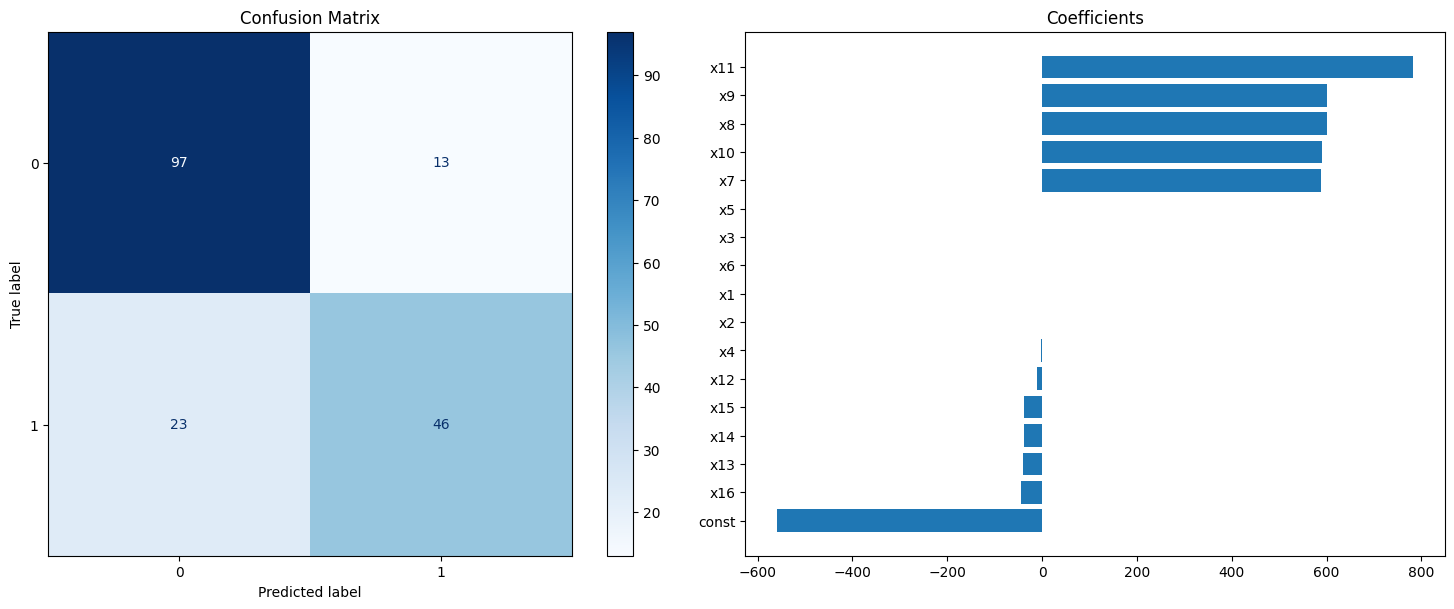

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import CalibrationDisplay

# ==========================================================
# TRAINING DIAGNOSTICS
# ==========================================================

train_prob = glm_model.predict(X_train_const)

influence = glm_model.get_influence()

deviance = glm_model.resid_deviance
pearson = glm_model.resid_pearson
cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

# ==========================================================
# TEST PREDICTIONS
# ==========================================================

test_prob = glm_model.predict(X_test_const)
test_pred = (test_prob >= 0.5).astype(int)

# ==========================================================
# DIAGNOSTIC DASHBOARD
# ==========================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# ----------------------------------------------------------
# Deviance Residuals
# ----------------------------------------------------------

axes[0,0].scatter(train_prob, deviance, alpha=0.6)
axes[0,0].axhline(0,color="red",ls="--")
axes[0,0].set_title("Deviance Residuals")
axes[0,0].set_xlabel("Predicted probability")
axes[0,0].set_ylabel("Residual")

# ----------------------------------------------------------
# Pearson Residuals
# ----------------------------------------------------------

axes[0,1].scatter(train_prob, pearson, alpha=0.6)
axes[0,1].axhline(0,color="red",ls="--")
axes[0,1].set_title("Pearson Residuals")
axes[0,1].set_xlabel("Predicted probability")

# ----------------------------------------------------------
# Histogram
# ----------------------------------------------------------

axes[0,2].hist(deviance, bins=30)
axes[0,2].set_title("Residual Histogram")

# ----------------------------------------------------------
# QQ Plot
# ----------------------------------------------------------

sm.qqplot(
    deviance,
    line="45",
    fit=True,
    ax=axes[1,0]
)

axes[1,0].set_title("QQ Plot")

# ----------------------------------------------------------
# Cook's Distance
# ----------------------------------------------------------

markerline, stemlines, baseline = axes[1,1].stem(
    np.arange(len(cooks)),
    cooks,
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" "
)

axes[1,1].axhline(4/len(cooks),color="red",ls="--")
axes[1,1].set_title("Cook's Distance")

# ----------------------------------------------------------
# Leverage vs Cook
# ----------------------------------------------------------

axes[1,2].scatter(leverage,cooks,alpha=0.6)

axes[1,2].set_xlabel("Leverage")
axes[1,2].set_ylabel("Cook's D")
axes[1,2].set_title("Influence")

# ----------------------------------------------------------
# ROC
# ----------------------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[2,0]
)

axes[2,0].set_title("ROC")

# ----------------------------------------------------------
# Precision Recall
# ----------------------------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[2,1]
)

axes[2,1].set_title("Precision Recall")

# ----------------------------------------------------------
# Calibration
# ----------------------------------------------------------

CalibrationDisplay.from_predictions(
    y_test,
    test_prob,
    n_bins=10,
    ax=axes[2,2]
)

axes[2,2].set_title("Calibration")

plt.tight_layout()
plt.show()

# ==========================================================
# CONFUSION MATRIX + COEFFICIENTS
# ==========================================================

fig, axes = plt.subplots(1,2,figsize=(15,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    ax=axes[0],
    cmap="Blues"
)

axes[0].set_title("Confusion Matrix")

coef = pd.DataFrame({
    "Feature": glm_model.model.exog_names,
    "Coefficient": glm_model.params
}).sort_values("Coefficient")

axes[1].barh(
    coef["Feature"],
    coef["Coefficient"]
)

axes[1].set_title("Coefficients")

plt.tight_layout()
plt.show()

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


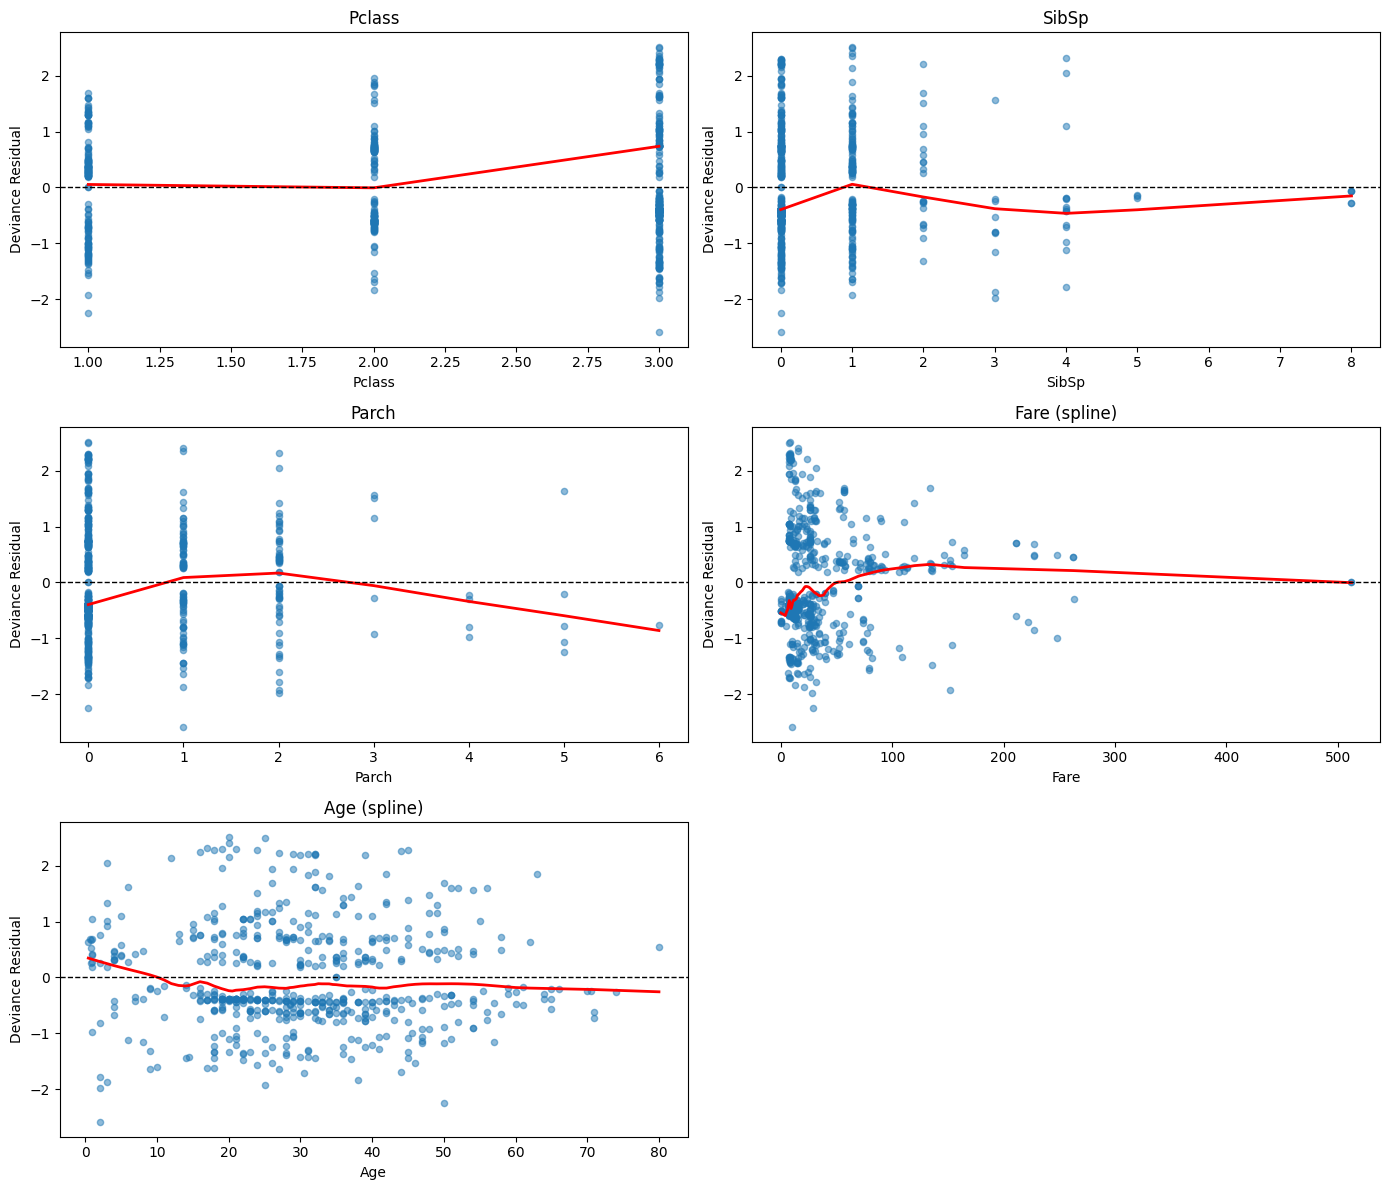

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Columns you actually want to check — linear numeric + splined ones together
linear_numeric_cols = preprocessor.named_transformers_["num"].feature_names_in_.tolist()
spline_cols_used = preprocessor.named_transformers_["spline"].named_steps["imputer"].feature_names_in_.tolist() \
    if "spline" in preprocessor.named_transformers_ else []

all_continuous = linear_numeric_cols + spline_cols_used

resid = glm_model.resid_deviance  # aligned to y_train / X_train_df row order

n_cols = 2
n_rows = int(np.ceil(len(all_continuous) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, feature in enumerate(all_continuous):

    x = X_train_df[feature].values  # RAW values, not the spline basis columns

    # drop rows where x is NaN (imputation happens inside the pipeline,
    # not in this raw column, so NaNs may still be here)
    mask = ~np.isnan(x)

    axes[i].scatter(x[mask], resid[mask], alpha=0.5, s=20)

    smooth = lowess(resid[mask], x[mask], frac=0.3, return_sorted=True)
    axes[i].plot(smooth[:, 0], smooth[:, 1], color="red", linewidth=2)

    axes[i].axhline(0, color="black", linestyle="--", linewidth=1)

    tag = " (spline)" if feature in spline_cols_used else ""
    axes[i].set_title(feature + tag)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Deviance Residual")

for j in range(len(all_continuous), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()